In [1]:
import scanpy
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
from datetime import datetime

from scmappy import *

from distinctipy import distinctipy

In [2]:
annotate = False

# Parameters

In [3]:
files = (
    "48h",
    "72h",
    "96h",
    "120h", 
    "144h",
)

In [4]:
dataset_reference = "pijuan"

# Annotate by stage and project comparatively

In [5]:
adata_reference = scanpy.read(f"data_other_studies/pijuan.h5ad")

In [6]:
if annotate:
    
    adata_reference = scanpy.read(f"data_other_studies/pijuan.h5ad")
    adata_reference.var_names = adata_reference.var["gene_ids"]

    for file in files:

        print(f"{datetime.now()} - Processing file: {file}")

        adata = scanpy.read(f"data/dias_{file}_EM_processed_annotated_plotting.h5ad")

        adata.var_names = adata.var["ENS"].apply(lambda x : x.split(".")[0])
        adata.layers["counts_log1p"] = adata.layers["counts"].log1p()

        scmap_projection(adata, adata_reference, "X_umap", knn=1, key_layer="counts_log1p")
        scmap_annotate(adata, adata_reference, "stage", algorithm_flavor="cell", knn=5, key_layer="counts_log1p", similarity_threshold=.5, key_added="annotation_stage")
        scmap_annotate(adata, adata_reference, "annotation", algorithm_flavor="cell", knn=5, key_layer="counts_log1p", similarity_threshold=.5, key_added="annotation_cell_type")
        adata.var.reset_index(inplace=True, drop=True)
        adata.write_h5ad(f"data/dias_{file}_EM_processed_annotated_plotting_curated_annotation.h5ad")

    del adata_reference

In [7]:
obs_total = []
X_total = []
X_ref = scanpy.read(f"data_other_studies/pijuan.h5ad").obsm["X_umap"]
hue_ref = scanpy.read(f"data_other_studies/pijuan.h5ad").obs["annotation"].values
for file in files:

    adata = scanpy.read(f"data/dias_{file}_EM_processed_annotated_plotting_curated_annotation.h5ad")

    obs = adata.obs
    obs["annotation_cell_type"] = adata.obs["annotation_cell_type"]
    obs["time"] = file
    obs_total.append(obs)

    X = adata.obsm["X_scmap_projection"]
    X_total.append(X)
obs_total = pd.concat(obs_total, axis=0)
X_total = np.vstack(X_total)

/Users/gatocor/miniforge3/envs/treeclust-scanpy/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/gatocor/miniforge3/envs/treeclust-scanpy/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/gatocor/miniforge3/envs/treeclust-scanpy/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/gatocor/miniforge3/envs/treeclust-scanpy/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/gatocor/miniforge3/envs/treeclust-scanpy/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


/var/folders/t9/0pk458_94qv27021t99vs5fr0000gn/T/ipykernel_4441/4110761605.py:28: UserWarning: The palette list has more values (38) than needed (30), which may not be intended.
  sns.scatterplot(x = X[:, 0], y = X[:, 1], hue = hue, s=10, palette = celltype_colors, ax=ax[3])


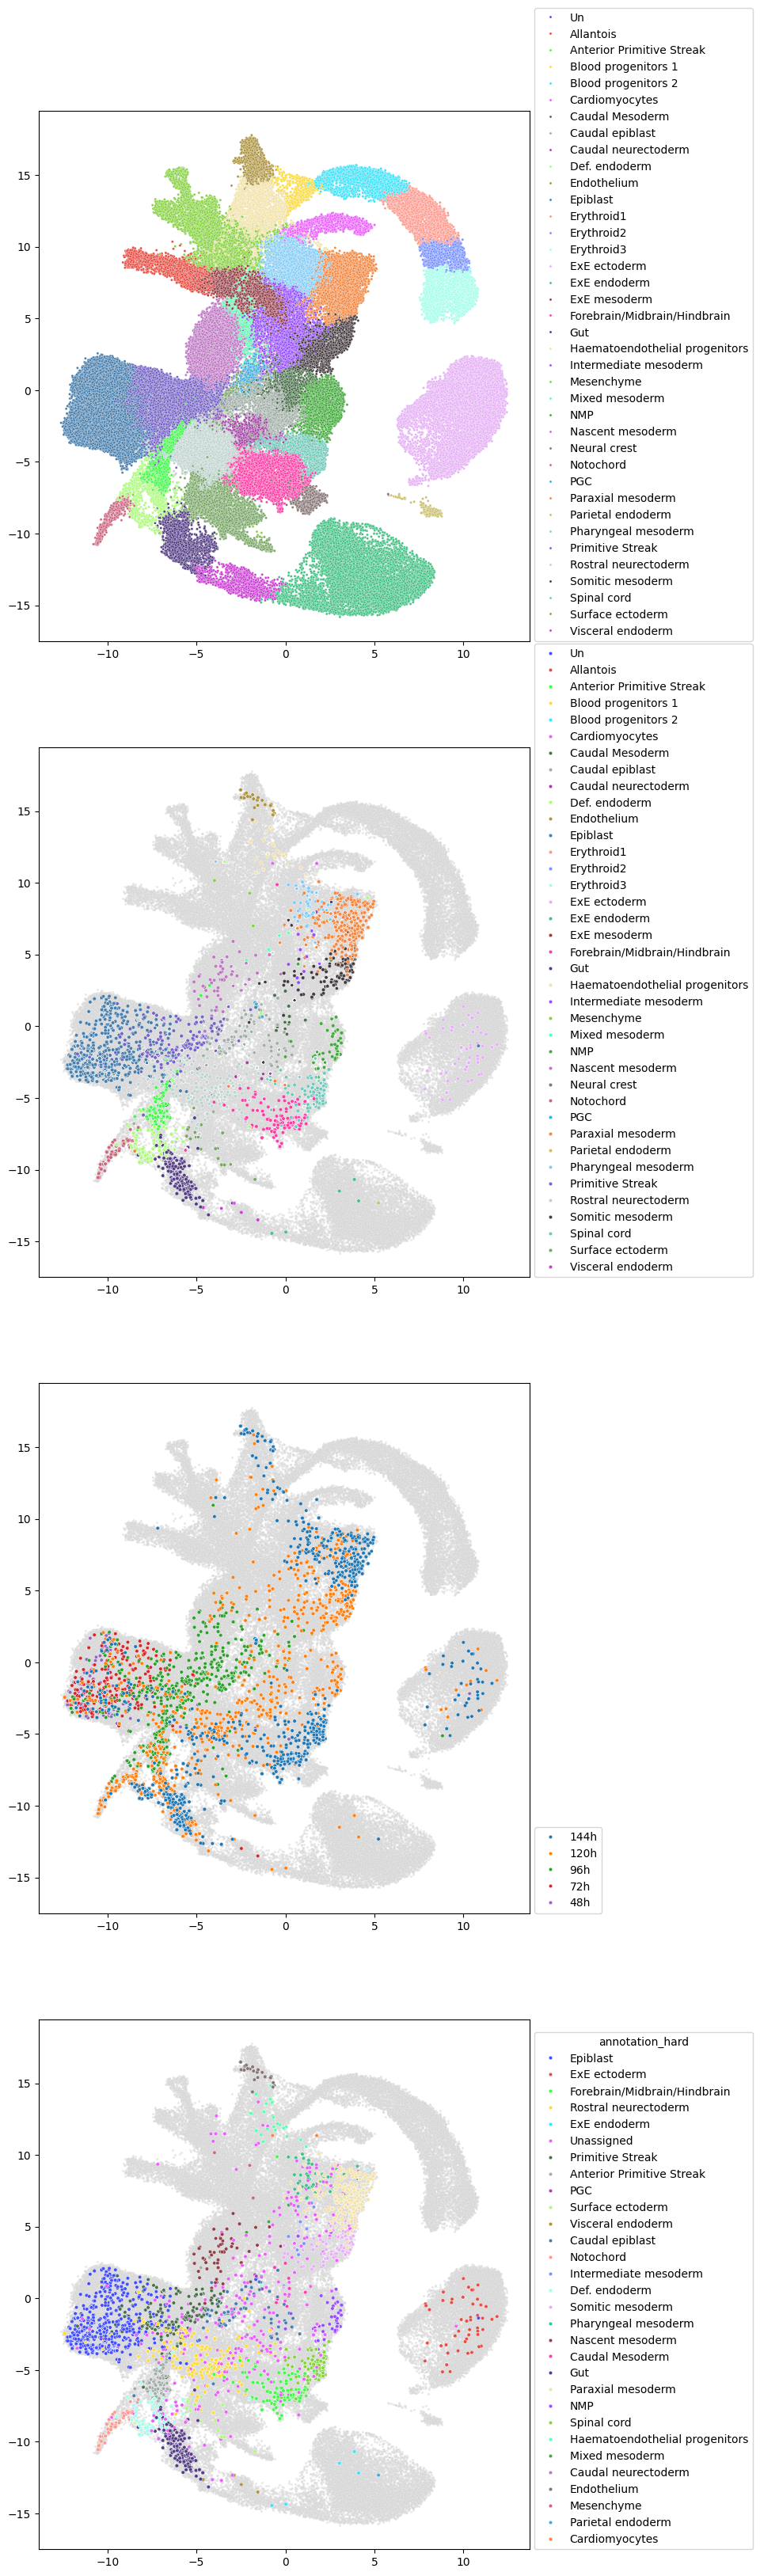

In [8]:
X = X_total
hue = obs_total["annotation_cell_type"].values

if isinstance(hue_ref[0], str):
    order = ["Un"] + [str(i) for i in np.sort(hue_ref.unique())]
else:
    order = ["Un"] + [str(i) for i in range(0, len(hue_ref.unique()))]
palette = ["black"]+sns.color_palette("Paired")+sns.color_palette("Set2", len(order))+sns.color_palette("Set1", len(order))

fig, ax = plt.subplots(4,1,figsize=(8, 40))

celltype_colors = distinctipy.get_colors(len(order), pastel_factor=0.3, rng=0)
sns.scatterplot(x = X_ref[:, 0], y = X_ref[:, 1], s=5, hue = hue_ref, hue_order=order, palette=celltype_colors, ax=ax[0])
ax[0].legend(loc=(1.01,0))

sns.scatterplot(x = X_ref[:, 0], y = X_ref[:, 1], color = "lightgray", s=5, alpha = 0.5, ax=ax[1])
sns.scatterplot(x = X[:, 0], y = X[:, 1], hue = hue, hue_order=order, s=10, palette = celltype_colors, ax=ax[1])
ax[1].legend(loc=(1.01,0))

hue = obs_total["time"].values
hue_order = ["48h", "72h", "96h", "120h", "144h"][::-1]
sns.scatterplot(x = X_ref[:, 0], y = X_ref[:, 1], color = "lightgray", s=5, alpha = 0.5, ax=ax[2])
sns.scatterplot(x = X[:, 0], y = X[:, 1], hue = hue, hue_order=hue_order, s=10, palette = None, ax=ax[2])
ax[2].legend(loc=(1.01,0))

hue = obs_total["annotation_cell_type"].values
sns.scatterplot(x = X_ref[:, 0], y = X_ref[:, 1], color = "lightgray", s=5, alpha = 0.5, ax=ax[3])
sns.scatterplot(x = X[:, 0], y = X[:, 1], hue = hue, s=10, palette = celltype_colors, ax=ax[3])
ax[3].legend(loc=(1.01,0), title="annotation_hard")

fig.savefig(f"figures/scmap_dias_UMAP_projection_{dataset_reference}.svg", bbox_inches='tight', transparent=True)

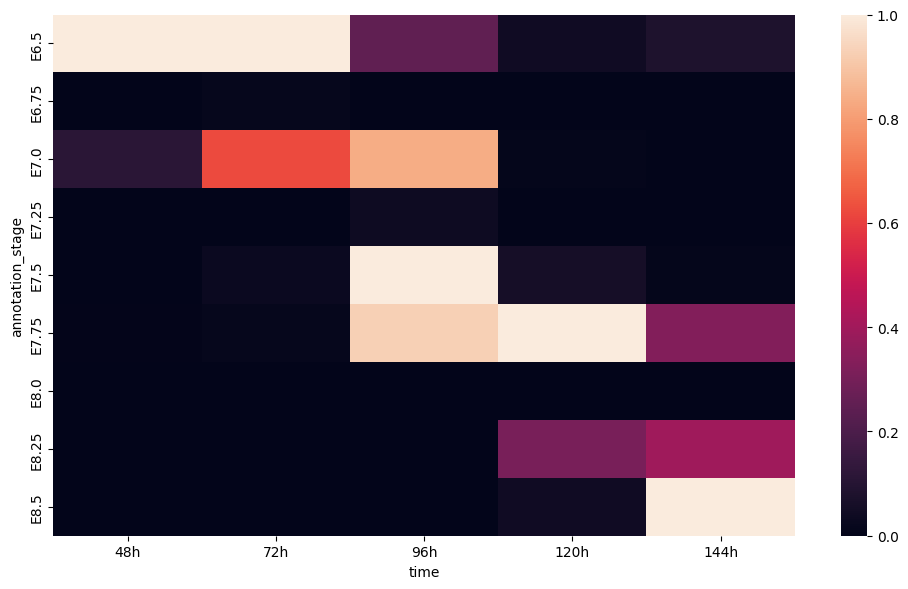

In [9]:
order = ["48h", "72h", "96h", "120h", "144h"]
order_rows=["E6.5","E6.75","E7.0","E7.25","E7.5","E7.75","E8.0","E8.25","E8.5"]

table = obs_total.groupby(["annotation_stage","time"]).count().iloc[:,0].unstack()
table = table.loc[order_rows,order].fillna(0)
table = table.div(table.max(axis=0), axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(table, vmax=1, ax=ax)
fig.tight_layout()
fig.savefig(f"figures/scmap_dias_reference_stage_gastruloid_time.svg", bbox_inches="tight")

/var/folders/t9/0pk458_94qv27021t99vs5fr0000gn/T/ipykernel_4441/1441747034.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


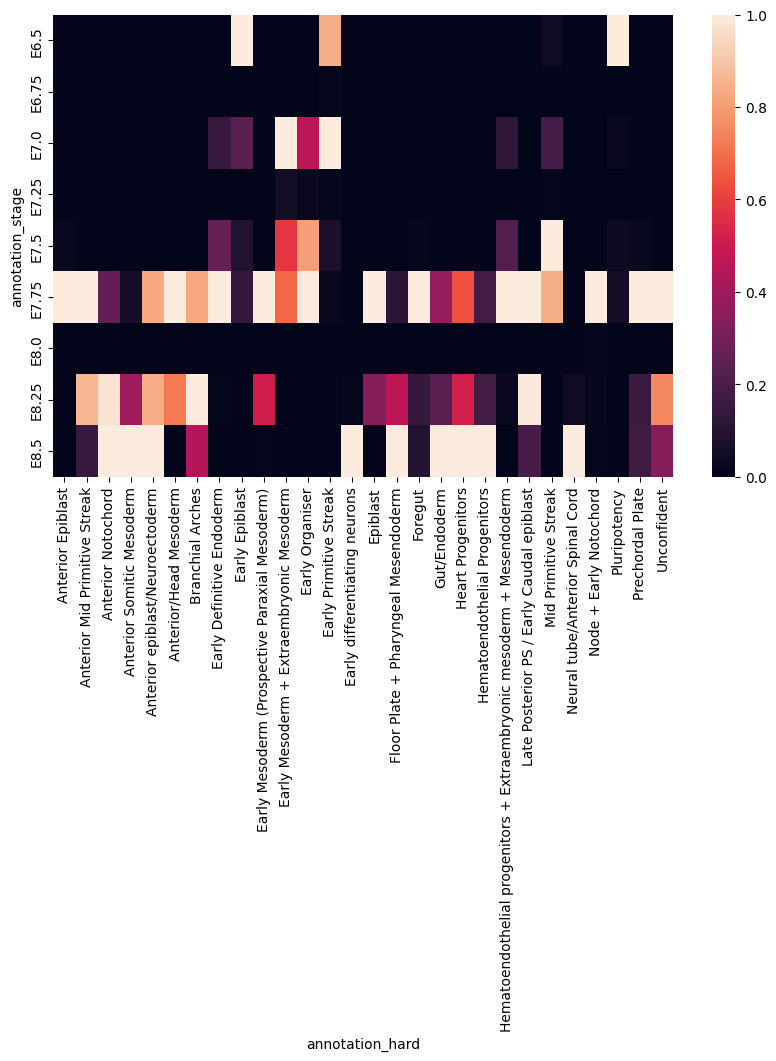

In [10]:
order_rows=["E6.5","E6.75","E7.0","E7.25","E7.5","E7.75","E8.0","E8.25","E8.5"]

table = obs_total.groupby(["annotation_stage","annotation_hard"]).count().iloc[:,0].unstack()
table = table.loc[order_rows,:].fillna(0)
table = table.div(table.max(axis=0), axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(table, vmax=1, ax=ax)
fig.tight_layout()
fig.savefig(f"figures/scmap_dias_reference_stage_gastruloid_annotation.svg", bbox_inches="tight")

In [11]:
hue_ref.unique()

['Epiblast', 'Primitive Streak', 'ExE ectoderm', 'Visceral endoderm', 'ExE endoderm', ..., 'Cardiomyocytes', 'Erythroid2', 'NMP', 'Erythroid3', 'Neural crest']
Length: 37
Categories (37, object): ['Allantois', 'Anterior Primitive Streak', 'Blood progenitors 1', 'Blood progenitors 2', ..., 'Somitic mesoderm', 'Spinal cord', 'Surface ectoderm', 'Visceral endoderm']

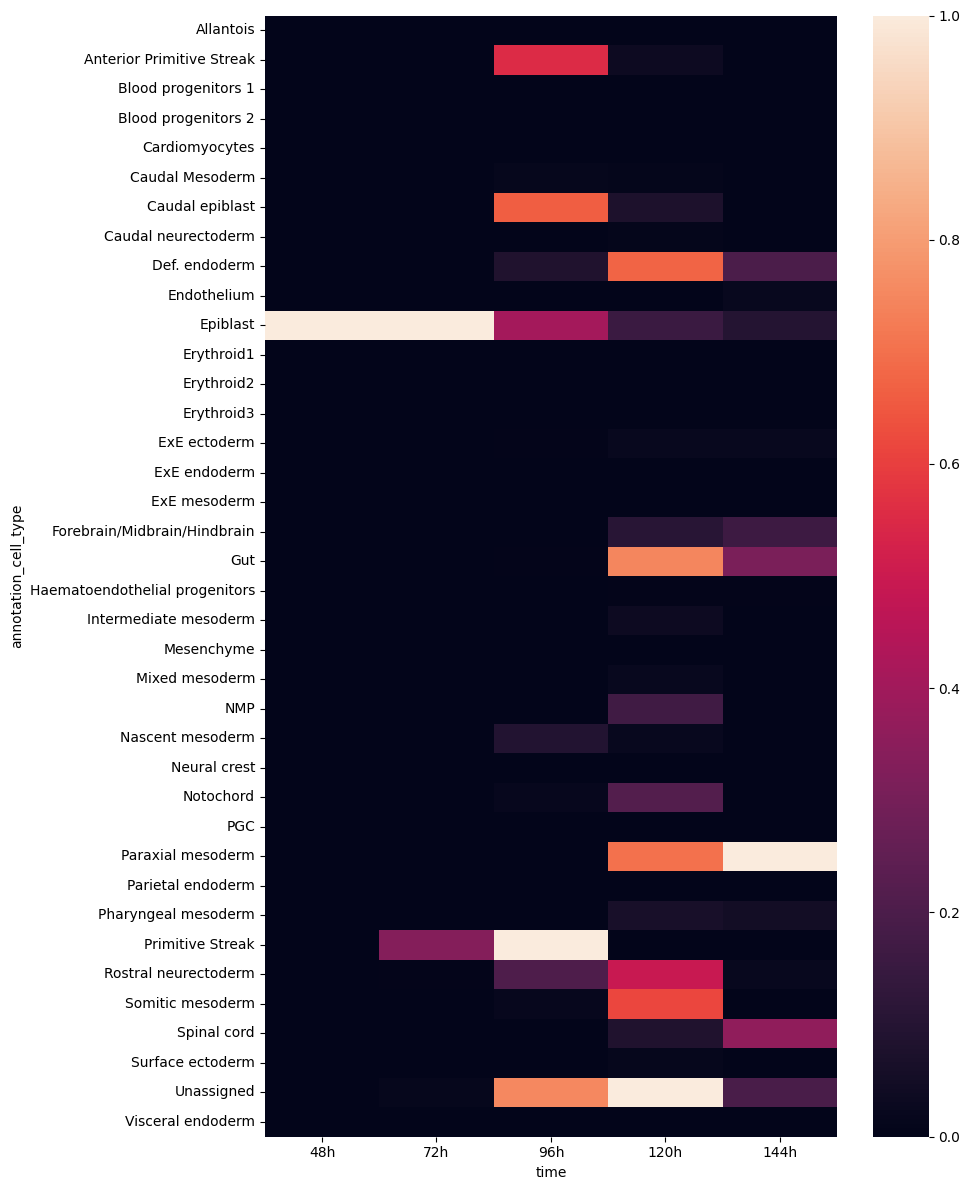

In [12]:
order = ["48h", "72h", "96h", "120h", "144h"]

table = obs_total.groupby(["annotation_cell_type","time"]).count().iloc[:,0].unstack()
for i in hue_ref.unique():
    if i not in table.index:
        table.loc[i] = [0]*len(order)
table = table.loc[:,order].fillna(0)
table = table.div(table.max(axis=0), axis=1)

table = table.sort_index()
fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(table, vmax=None, ax=ax)
fig.tight_layout()
fig.savefig(f"figures/scmap_dias_reference_annotation_gastruloid_time.svg", bbox_inches="tight")

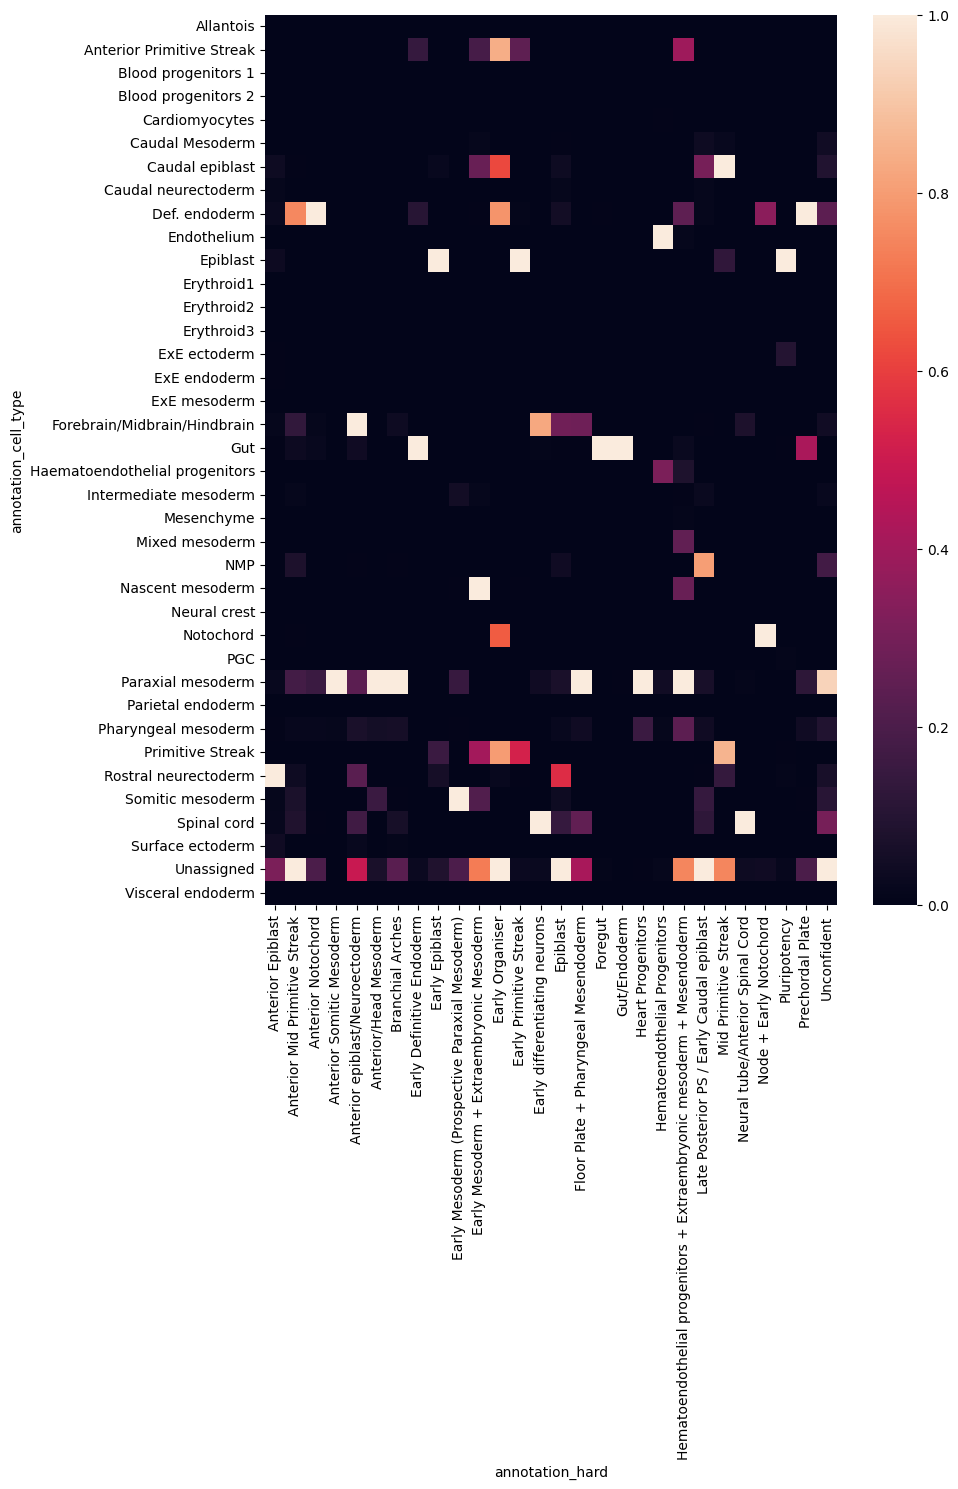

In [13]:
table = obs_total.groupby(["annotation_cell_type","annotation_hard"]).count().iloc[:,0].unstack()
for i in hue_ref.unique():
    if i not in table.index:
        table.loc[i] = [0]*len(table.columns)
table = table.div(table.max(axis=0), axis=1).fillna(0)
table = table.sort_index()

fig, ax = plt.subplots(figsize=(10, 15))
sns.heatmap(table, vmax=1, ax=ax, )
fig.tight_layout()
fig.savefig(f"figures/scmap_dias_reference_annotation_gastruloid_annotation.svg", bbox_inches="tight")